In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import pywt
import torch.optim as optim
import glob
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
# 检查CUDA是否可用
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Main_path = 'D:\\Desktop\\Desktop\\Python\\Forward_and_Inverse_problem\\'
Data_path = f'{Main_path}Data\\'
Save_path = f'{Main_path}Nonlinear_verification\\Python_nonlinear_verification3\\'

Using device: cuda:0


In [3]:
M = 9900
A = 1
data = []
labels = []
skipped_files = []  # 记录跳过的文件

# 拿到数据路径，方便后续读取
dir_path = f'{Data_path}Experiment_signal'
# 获取目录及其子目录下所有CSV文件的路径
dataPaths = sorted(glob.glob(os.path.join(dir_path, '**', '*.csv'), recursive=True))
random.seed(42)
random.shuffle(dataPaths)

# 遍历读取数据
for dataPath in dataPaths:
    # 读取数据（先读取，后验证）
    data_1 = pd.read_csv(dataPath)
    
    # 检查第一列的每一行，找到第一个大于0的值的位置N
    N = 0
    for i in range(len(data_1)):
        if data_1.iloc[i, 1] != 0:
            N = i
            break
    
    # 【关键修复】先验证数据长度，不够就跳过整个文件
    if N >= len(data_1) - M + 1:
        filename = os.path.basename(dataPath)
        print(f"警告：跳过 {filename} - 数据不足(可用{len(data_1)-N}点，需要{M}点)")
        skipped_files.append(filename)
        continue  # 跳过这个文件，data和labels都不添加
    
    # 只有数据足够时，才提取数据和标签
    data.append(data_1.iloc[N:N+M, 1].values)
    
    # 提取标签（移到验证之后）
    filename = os.path.basename(dataPath)
    parts = filename.split('_')
    label1 = float(parts[2])
    label2 = float(parts[3])
    labels.append([label1, label2])

print(f"\n处理完成：成功{len(data)}个，跳过{len(skipped_files)}个")

# 将数据和标签转换为numpy数组
all_datas = np.array(data, dtype="float")
all_labels = np.array(labels)

# 直接按照7:2:1的比例划分
# 首先分出训练集（70%）和临时集（30%）
train_datas, temp_datas, train_labels, temp_labels = train_test_split(
    all_datas, all_labels, test_size = 0.3, random_state=42
)

# 然后将临时集按照2:1的比例划分为验证集和测试集
# 2:1相当于验证集占2/3，测试集占1/3
validation_datas, test_data, validation_labels, test_labels = train_test_split(
    temp_datas, temp_labels, test_size=1/2, random_state=42
)

# 输出数据集的形状以确认
print("训练集数据形状:", train_datas.shape)
print("验证集数据形状:", validation_datas.shape)
print("测试集数据形状:", test_data.shape)


处理完成：成功864个，跳过0个
训练集数据形状: (604, 9900)
验证集数据形状: (130, 9900)
测试集数据形状: (130, 9900)


In [4]:
test_datas = test_data.reshape(-1,test_data.shape[1],1)
print(test_datas.shape)

(130, 9900, 1)


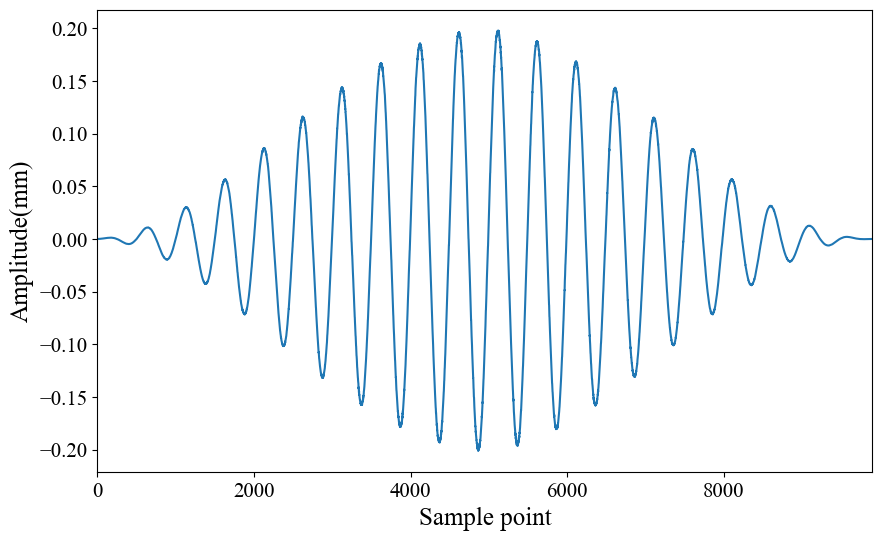

In [5]:
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(test_datas[9],linewidth=1.5)
plt.xlabel('Sample point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(mm)',fontdict={'weight': 'normal', 'size': 18})
#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlim([0,M])
plt.savefig(f'{Save_path}test_data.jpg', dpi=600, bbox_inches='tight')

In [11]:
BATCH_SIZE = 1
input_size = 1243
hidden_size = 64
num_layers = 2
output_size = 2

In [12]:
test_dataset = TensorDataset(torch.from_numpy(test_datas),torch.from_numpy(test_labels))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
class ConvAutoencoderPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate):
        super().__init__()
        self.input_size = input_size
        self.device = device
        
        # ---------- 卷积编码器 ----------
        self.encoder = nn.Sequential(
            nn.Conv1d(input_size, hidden_size*4, 5, stride=2, padding=2),
            nn.BatchNorm1d(hidden_size*4), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Conv1d(hidden_size*4, hidden_size*2, 3, stride=2, padding=1),
            nn.BatchNorm1d(hidden_size*2), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Conv1d(hidden_size*2, hidden_size, 3, stride=1, padding=1),
            nn.BatchNorm1d(hidden_size), nn.ReLU(), nn.Dropout(dropout_rate),
        )

        # ---------- 卷积解码器 ----------
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(hidden_size, hidden_size*2, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm1d(hidden_size*2), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.ConvTranspose1d(hidden_size*2, hidden_size*4, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm1d(hidden_size*4), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.ConvTranspose1d(hidden_size*4, input_size, 5, stride=1, padding=2),
        )

        # ---------- 2 层双向 LSTM ----------
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            bidirectional=True,
                            dropout=dropout_rate if num_layers > 1 else 0,
                            batch_first=False)
        
        self.dropout_layer = nn.Dropout(dropout_rate)
        self.regressor = nn.Linear(2 * hidden_size, output_size)

    def forward(self, x):
        wavelet = 'db4'
        # 将张量移动至CPU上面
        x1 = x.cpu()

        # 将CPU张量转化为numpy
        x2 = x1.numpy()
        # 离散小波分解
        coeffs = pywt.wavedec(x2, wavelet, level=6)
        xh1 = coeffs[6]
        xh2 = coeffs[5]
        xh3 = coeffs[4]
        xh4 = coeffs[3]
        xh5 = coeffs[2]
        xh6 = coeffs[1]
        xl6 = coeffs[0]
        # 连接分解后的序列
        x3 = xh3

        x4 = torch.from_numpy(x3)
        x5 = x4.to(device)
        
        x_conv = x5.permute(0, 2, 1)
        encoded = self.encoder(x_conv)
        decoded = self.decoder(encoded)

        out = decoded.view(decoded.size(0), -1)
        out = out.view(out.size(0), -1, self.input_size)

        lstm_out, _ = self.lstm(out) 
        lstm_out = lstm_out[:, -1, :]

        out = self.dropout_layer(lstm_out)
        out = self.regressor(out)  
        return out

In [14]:
model=torch.load(f'{Save_path}\\Inverse_Model_3.pth')
model.to(device)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8116\576706153.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model=torch.load(f'{Save_path}\\Inverse_Model_3.pth')


ConvAutoencoderPredictor(
  (encoder): Sequential(
    (0): Conv1d(1243, 256, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Conv1d(256, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.0, inplace=False)
    (8): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.0, inplace=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): ConvTranspose1d(1

In [15]:
# 将模型设置为评估模式
model.eval()  
# 进行预测

force_test=[]
HI_test=[]

force_pred = []
HI_pred = []
for i, (x, y) in enumerate(test_loader):

    x1=x.type(torch.FloatTensor)
    x2 = x1.permute(0,2,1) #将x1的维度进行调换，该例中将第1个维度保持不变，第2个维度和第3个进行交换
    x3,y=x2.to(device),y.to(device)
    
    force = y[:,0]
    HI = y[:,1]

    force_test.append(force.item())
    HI_test.append(HI.item())

    with torch.no_grad():  # 关闭梯度计算
        outputs = model(x3)
        force_pred.append(outputs[:,0].item())
        HI_pred.append(outputs[:,1].item())

In [16]:
force_pred1 = np.array(force_pred)

HI_pred1 = np.array(HI_pred)

from sklearn.metrics import r2_score
r2_force = r2_score(test_labels[:,0], force_pred1)
print(f'R² Score for force: {r2_force:.2f}')

r2_HI = r2_score(test_labels[:,1], HI_pred1)
print(f'R² Score for HI: {r2_HI:.2f}')

R² Score for force: 0.94
R² Score for HI: 0.94


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse_force = mean_squared_error(test_labels[:,0], force_pred)
print(f'MSE_force: {mse_force:.3f}:')

mse_HI = mean_squared_error(test_labels[:,1], HI_pred)
print(f'MSE_HI: {mse_HI:.3f}:')

# 计算 MAE
mae_force = mean_absolute_error(test_labels[:,0], force_pred)
print(f'MAE_force: {mae_force:.3f}')

mae_HI = mean_absolute_error(test_labels[:,1], HI_pred)
print(f'MAE_HI: {mae_HI:.3f}')

MSE_force: 1.460:
MSE_HI: 0.002:
MAE_force: 0.893
MAE_HI: 0.030


In [18]:
def mape(y_true, y_pred):
    n = len(y_true)
    if n == 0:
        return 0
    errors = np.abs((y_true - y_pred) / y_true)
    return np.mean(errors) * 100

# test_labels是二维的numpy数组，[:, 0]表示取第一列作为长度相关的真实值
# force_pred是对应的长度预测值
mape_force = mape(test_labels[:, 0], force_pred)
print(f'MAPE_force: {mape_force:.3f}')

mape_HI = mape(test_labels[:, 0], HI_pred)
print(f'MAPE_HI: {mape_HI:.3f}')

MAPE_force: 7.853
MAPE_HI: 96.819


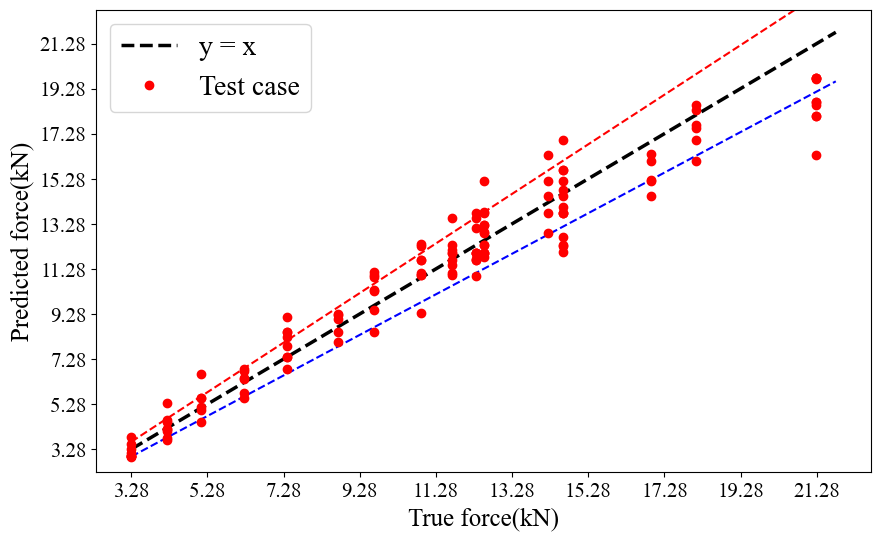

In [19]:
# 绘图命令
plt.style.use('default')
plt.figure(figsize=(10, 6)) #创建Figure对象，并指定尺寸
plt.rcParams['font.family'] = ['Times New Roman']
force_true=np.arange(np.min(test_labels[:,0]),np.max(test_labels[:,0])+1,0.5)
plt.plot(force_true,force_true,'k--', label='y = x',linewidth=2.5)

plt.plot(force_true, 1.1*force_true,'r--',linewidth=1.5)
plt.plot(force_true, 0.9*force_true,'b--',linewidth=1.5)

# 绘制红色实心圆
plt.plot(test_labels[:,0],force_pred1, marker='o', markersize=6, color='red', linestyle='None',label='Test case')

#plt.text(8, 2, f'R\u00B2={r2:.2f}', fontsize=20, color='black')  # 在坐标 (2, 0) 位置插入文本

plt.xlabel('True force(kN)',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Predicted force(kN)',fontdict={'weight': 'normal', 'size': 18})

# 设置坐标轴刻度
plt.xticks(np.arange(force_true.min(),force_true.max()+1,2))  
plt.yticks(np.arange(force_true.min(),force_true.max()+1,2)) 

plt.ylim([force_true.min()-1, force_true.max()+1]) 

#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15) 

plt.legend(fontsize=20)

plt.savefig(f'{Save_path}Force_precidtion.jpg', dpi=600, bbox_inches='tight')

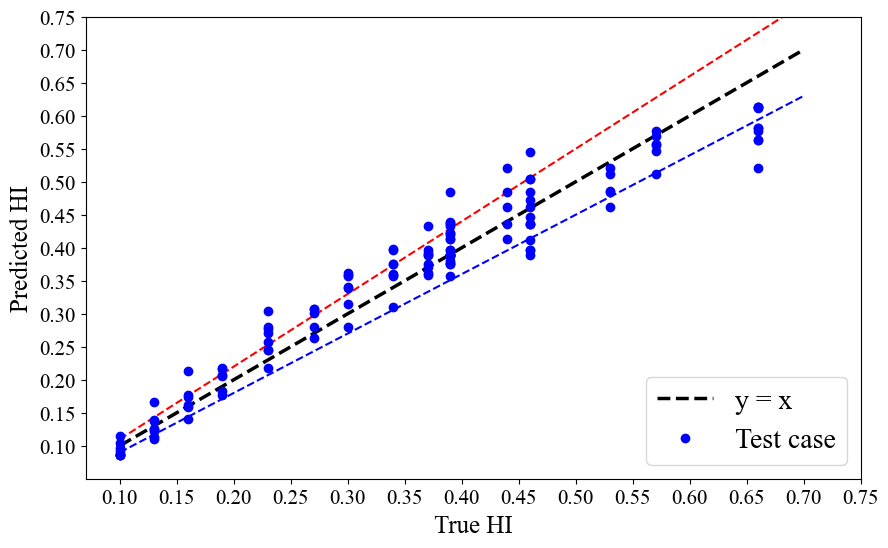

In [20]:
# 绘图命令
plt.style.use('default')
plt.figure(figsize=(10, 6)) #创建Figure对象，并指定尺寸
plt.rcParams['font.family'] = ['Times New Roman']
HI_true=np.arange(np.min(test_labels[:,1]),np.max(test_labels[:,1])+0.05,0.05)
plt.plot(HI_true,HI_true,'k--', label='y = x',linewidth=2.5)

plt.plot(HI_true, 1.1*HI_true,'r--',linewidth=1.5)
plt.plot(HI_true, 0.9*HI_true,'b--',linewidth=1.5)

# 绘制红色实心圆
plt.plot(test_labels[:,1],HI_pred1, marker='o', markersize=6, color='blue', linestyle='None',label='Test case')

#plt.text(8, 2, f'R\u00B2={r2:.2f}', fontsize=20, color='black')  # 在坐标 (2, 0) 位置插入文本

plt.xlabel('True HI',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Predicted HI',fontdict={'weight': 'normal', 'size': 18})

# 设置坐标轴刻度
plt.xticks(np.arange(HI_true.min(),HI_true.max()+0.05,0.05))  
plt.yticks(np.arange(HI_true.min(),HI_true.max()+0.05,0.05))

plt.ylim([HI_true.min()-0.05, HI_true.max()+0.05]) 

#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15) 

plt.legend(fontsize=20,loc='lower right')

plt.savefig(f'{Save_path}HI_precidtion.jpg', dpi=600, bbox_inches='tight')